# 📊 Classification automatique des activités (CRISP-DM) — V2

Améliorations :
- Chargement CSV robuste
- Détection dynamique des colonnes
- Labellisation améliorée
- Équilibrage des classes + class_weight
- Matrice de confusion + comparaison des modèles


## 1. 🎯 Business Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import resample

## 2. 📂 Data Understanding

In [ ]:
# Chargement robuste
df = pd.read_csv('JobsDatasetProcessed (2).csv', engine='python', on_bad_lines='skip')

print(df.head())
print(df.columns)

     ID                    Query                               Job Title  \
0  3859  Artificial Intelligence   Collaborative Manipulation Roboticist   
1  3764  Artificial Intelligence      Software Engineer - Innovation Lab   
2  3597  Artificial Intelligence          Director, Standards & Strategy   
3  3746  Artificial Intelligence            Business Strategy Consultant   
4  3872  Artificial Intelligence                       Regular Full-Time   

                                         Description  \
0  Location: Schlumberger-Doll Research, Cambridg...   
1  About DENSO DENSO is one of the largest global...   
2  As a Director of Strategy & Strategy at Xperi,...   
3  If you have a strategic mindset and expertise ...   
4  Mission Who We Are Founded and continuously le...   

                                           IT Skills  \
0  Collaborative Manipulation, Artificial Intelli...   
1  Software Development, Infotainment Systems, Au...   
2  Audio/video codec, Media streaming 

## 3. 🧹 Data Preparation

In [ ]:
# Détection dynamique des colonnes
cols = df.columns
text_cols = [col for col in cols if df[col].dtype == 'object']

# Fusion de toutes les colonnes texte
df['combined_text'] = df[text_cols].fillna('').agg(' '.join, axis=1)

# Nettoyage
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['combined_text'].apply(clean_text)

# Labellisation améliorée
def categoriser(text):
    tech = ['python','java','sql','data','developer','engineering','machine learning']
    mg = ['manager','lead','project','scrum','director','strategy']
    soft = ['communication','teamwork','leadership','adaptability','problem solving']

    if any(w in text for w in tech):
        return 'technique'
    elif any(w in text for w in mg):
        return 'managerial'
    else:
        return 'soft_skills'

df['category'] = df['clean_text'].apply(categoriser)

print(df['category'].value_counts())

category
technique      1576
managerial       46
soft_skills       6
Name: count, dtype: int64


## 4. ⚖️ Équilibrage des classes

In [ ]:
# Équilibrage
df_max = df['category'].value_counts().max()
dfs = []

for cat in df['category'].unique():
    df_cat = df[df['category'] == cat]
    df_cat_up = resample(df_cat, replace=True, n_samples=df_max, random_state=42)
    dfs.append(df_cat_up)

df_balanced = pd.concat(dfs)
df_balanced = df_balanced.sample(frac=1, random_state=42)

print(df_balanced['category'].value_counts())

category
soft_skills    1576
managerial     1576
technique      1576
Name: count, dtype: int64


## 5. 🤖 Modeling

In [ ]:
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X = vectorizer.fit_transform(df_balanced['clean_text'])

encoder = LabelEncoder()
y = encoder.fit_transform(df_balanced['category'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'SVM': SVC(class_weight='balanced')
}

## 6. 📈 Evaluation


Logistic Regression
Accuracy: 0.9947145877378436
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       315
           1       1.00      1.00      1.00       315
           2       1.00      0.98      0.99       316

    accuracy                           0.99       946
   macro avg       0.99      0.99      0.99       946
weighted avg       0.99      0.99      0.99       946


SVM
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       315
           1       1.00      1.00      1.00       315
           2       1.00      1.00      1.00       316

    accuracy                           1.00       946
   macro avg       1.00      1.00      1.00       946
weighted avg       1.00      1.00      1.00       946


Naive Bayes
Accuracy: 0.9915433403805497
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       315
           1      

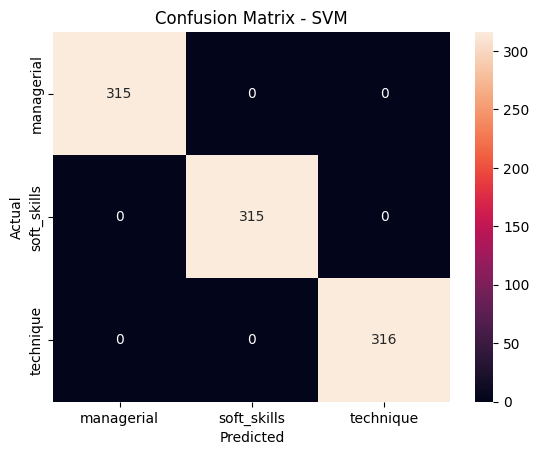

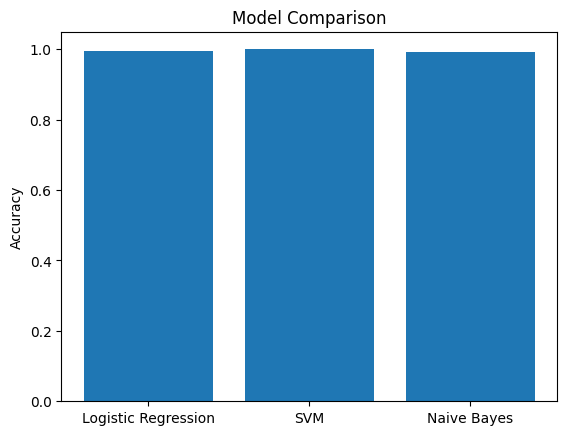

In [ ]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"\n{name}")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred, zero_division=0))

best_model_name = max(results, key=results.get)
print("\nBest Model:", best_model_name)

# Matrice de confusion
y_pred = models[best_model_name].predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Comparaison
plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
print('Models used in this notebook:')
for name in models.keys():
    print(f'- {name}')

Models used in this notebook:
- Logistic Regression
- SVM
- Naive Bayes


## 7. 🚀 Deployment

In [ ]:
def predict_activity(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    pred = models[best_model_name].predict(vec)
    return encoder.inverse_transform(pred)[0]

print(predict_activity('manage project team and communication'))

technique
